# 한국어 Transformer 챗봇 만들기

이 노트북에서는 **한국어 일상 대화 데이터셋(ChatbotData)**을 활용하여 Transformer 아키텍처 기반의 챗봇을 처음부터 구현합니다.

## 전체 파이프라인

| 단계 | 내용 |
|------|------|
| Step 1 | 데이터 수집 (ChatbotData.csv 다운로드) |
| Step 2 | 데이터 전처리 (텍스트 정제, 분리) |
| Step 3 | SentencePiece 토크나이저 학습 및 적용 |
| Step 4 | Transformer 모델 구성 및 학습 |
| Step 5 | 모델 평가 및 챗봇 테스트 |

## 사용 기술
- **데이터**: [songys/Chatbot_data](https://github.com/songys/Chatbot_data) — 한국어 일상/감성 대화 약 12,000쌍
- **토크나이저**: SentencePiece (BPE 방식)
- **모델**: Transformer (Vaswani et al., 2017 *Attention is All You Need*)
- **프레임워크**: TensorFlow 2.x / Keras


---
## Step 1. 데이터 수집

### ChatbotData 소개

**ChatbotData**는 송영숙님이 공개한 한국어 챗봇 학습용 데이터셋으로, 총 **11,823쌍**의 질문-답변 데이터를 포함합니다.

| 컬럼 | 설명 |
|------|------|
| `Q`  | 질문 (사용자 발화) |
| `A`  | 답변 (챗봇 응답) |
| `label` | 감정 레이블 (0: 일상, 1: 이별/부정, 2: 사랑/긍정) |

### 터미널에서 직접 다운로드
```bash
mkdir -p ~/work/transformer_chatbot/data/
cd ~/work/transformer_chatbot/data/
wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
```

아래 코드 셀에서 Python으로 자동 다운로드도 가능합니다.


In [1]:
# 필요한 외부 라이브러리 설치
!pip install sentencepiece -q
!pip install nltk -q

import os
import urllib.request
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

print('라이브러리 로드 완료!')


라이브러리 로드 완료!


In [2]:
os.makedirs('data', exist_ok=True)

DATA_URL  = 'https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv'
DATA_PATH = 'data/ChatbotData.csv'

if not os.path.exists(DATA_PATH):
    print('데이터 다운로드 중...')
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print('다운로드 완료!')
else:
    print('기존 다운로드 파일 사용')

df = pd.read_csv(DATA_PATH)
print(f'\n데이터 크기: {df.shape}')
print(f'컬럼: {list(df.columns)}')
df.head(10)


데이터 다운로드 중...
다운로드 완료!

데이터 크기: (11823, 3)
컬럼: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
5,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.,0
6,SD카드 안돼,다시 새로 사는 게 마음 편해요.,0
7,SNS 맞팔 왜 안하지ㅠㅠ,잘 모르고 있을 수도 있어요.,0
8,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.,0
9,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.,0


---
## Step 2. 데이터 전처리

원본 텍스트에는 불필요한 특수문자, 중복 공백, 이모지 등이 포함될 수 있습니다.
챗봇 학습에 방해가 되는 노이즈를 제거하고 데이터를 정규화합니다.

### 전처리 단계
1. **텍스트 정제**: 한글, 영문, 숫자, 기본 문장부호만 남기고 나머지 제거
2. **공백 정규화**: 연속 공백을 단일 공백으로 치환
3. **빈 문장 제거**: 전처리 후 빈 문자열이 된 행 제거
4. **중복 제거**: Q-A 쌍이 완전히 동일한 중복 데이터 제거
5. **길이 분포 확인**: 모델의 최대 시퀀스 길이(`MAX_LEN`) 결정을 위한 통계 확인


In [3]:
def clean_text(text):
    """한글·영문·숫자·기본 문장부호만 남기고 정제"""
    text = re.sub(r'[^가-힣a-zA-Z0-9\s!?.,~]', '', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Q'] = df['Q'].apply(clean_text)
df['A'] = df['A'].apply(clean_text)

# 빈 문자열 및 중복 제거
df = df[(df['Q'].str.len() > 0) & (df['A'].str.len() > 0)]
df = df.drop_duplicates(subset=['Q', 'A']).reset_index(drop=True)

print(f'전처리 후 데이터 크기: {df.shape}')
df[['Q', 'A']].head(10)


전처리 후 데이터 크기: (11750, 3)


,Q,A
0,12시 땡!,하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.
5,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.
6,SD카드 안돼,다시 새로 사는 게 마음 편해요.
7,SNS 맞팔 왜 안하지,잘 모르고 있을 수도 있어요.
8,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.
9,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.


=== 문장 길이 통계 ===
Q 평균: 12.9  최대: 56
A 평균: 15.0  최대: 76


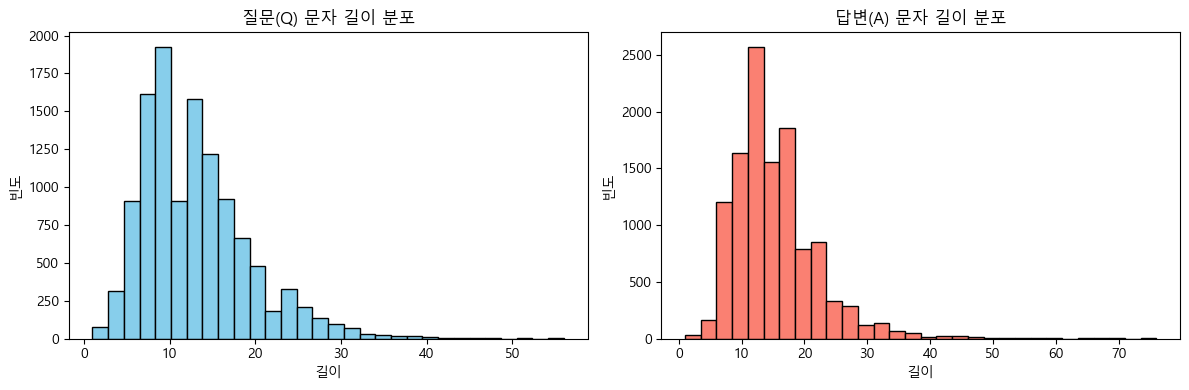


=== 레이블 분포 ===
  일상다반사: 5290개
  이별(부정): 3498개
  사랑(긍정): 2962개


In [4]:
df['Q_len'] = df['Q'].apply(len)
df['A_len'] = df['A'].apply(len)

print('=== 문장 길이 통계 ===')
print(f'Q 평균: {df["Q_len"].mean():.1f}  최대: {df["Q_len"].max()}')
print(f'A 평균: {df["A_len"].mean():.1f}  최대: {df["A_len"].max()}')

try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except Exception:
    pass
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Q_len'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('질문(Q) 문자 길이 분포')
axes[0].set_xlabel('길이')
axes[0].set_ylabel('빈도')
axes[1].hist(df['A_len'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('답변(A) 문자 길이 분포')
axes[1].set_xlabel('길이')
axes[1].set_ylabel('빈도')
plt.tight_layout()
plt.show()

label_names = {0: '일상다반사', 1: '이별(부정)', 2: '사랑(긍정)'}
print('\n=== 레이블 분포 ===')
for lbl, cnt in df['label'].value_counts().sort_index().items():
    print(f'  {label_names[lbl]}: {cnt}개')


---
## Step 3. SentencePiece 토크나이저

한국어는 형태소가 복잡하여 단순 공백 기반 분리가 어렵습니다.
**SentencePiece**는 언어에 독립적인 서브워드(subword) 토크나이저로, 언어 분석기 없이도 효과적으로 한국어를 분절합니다.

### BPE (Byte Pair Encoding)
- 가장 빈번하게 등장하는 문자 쌍을 반복적으로 병합하여 어휘를 구성
- OOV(Out-of-Vocabulary) 문제를 효과적으로 해결
- 어휘 크기를 유연하게 조절 가능

### 특수 토큰 구성
| 토큰 | ID | 역할 |
|------|----|------|
| `[PAD]`   | 0 | 패딩 (길이 맞춤) |
| `[UNK]`   | 1 | 미등록 단어 |
| `[START]` | 2 | 디코더 입력 시작 |
| `[END]`   | 3 | 디코더 출력 종료 |


In [5]:
import sentencepiece as spm

CORPUS_PATH  = 'data/corpus.txt'
MODEL_PREFIX = 'data/chatbot_spm'
VOCAB_SIZE   = 8000

# Q + A 문장을 하나의 코퍼스 파일로 저장
with open(CORPUS_PATH, 'w', encoding='utf-8') as f:
    for text in list(df['Q']) + list(df['A']):
        f.write(text + '\n')

print(f'코퍼스 생성 완료: {CORPUS_PATH}')

spm.SentencePieceTrainer.train(
    input=CORPUS_PATH,
    model_prefix=MODEL_PREFIX,
    vocab_size=VOCAB_SIZE,
    character_coverage=1.0,
    model_type='bpe',
    pad_id=0,  pad_piece='[PAD]',
    unk_id=1,  unk_piece='[UNK]',
    bos_id=2,  bos_piece='[START]',
    eos_id=3,  eos_piece='[END]'
)

sp = spm.SentencePieceProcessor()
sp.load(f'{MODEL_PREFIX}.model')

PAD_ID   = sp.pad_id()   # 0
START_ID = sp.bos_id()   # 2
END_ID   = sp.eos_id()   # 3

print(f'어휘 크기: {sp.get_piece_size()}')
print(f'PAD={PAD_ID}, START={START_ID}, END={END_ID}')

# 토크나이징 예시
examples = ['안녕하세요', '오늘 날씨 정말 좋다!', '사랑해요']
print('\n=== 토크나이징 예시 ===')
for text in examples:
    tokens = sp.encode_as_pieces(text)
    ids    = sp.encode_as_ids(text)
    print(f'원문 : {text}')
    print(f'토큰 : {tokens}')
    print(f'ID   : {ids}')
    print(f'복원 : {sp.decode_ids(ids)}')
    print()


코퍼스 생성 완료: data/corpus.txt
어휘 크기: 8000
PAD=0, START=2, END=3

=== 토크나이징 예시 ===
원문 : 안녕하세요
토큰 : ['▁안녕하세요']
ID   : [4579]
복원 : 안녕하세요

원문 : 오늘 날씨 정말 좋다!
토큰 : ['▁오늘', '▁날씨', '▁정말', '▁좋다', '!']
ID   : [125, 905, 209, 1737, 6920]
복원 : 오늘 날씨 정말 좋다!

원문 : 사랑해요
토큰 : ['▁사랑해요']
ID   : [5224]
복원 : 사랑해요



In [6]:
from sklearn.model_selection import train_test_split

MAX_LEN = 40  # 최대 시퀀스 길이 (통계 참고하여 결정)

def tokenize_and_pad(texts, max_len):
    """인코더 입력: 토큰 ID + 패딩"""
    result = []
    for text in texts:
        ids = sp.encode_as_ids(str(text))[:max_len]
        result.append(ids + [PAD_ID] * (max_len - len(ids)))
    return np.array(result, dtype=np.int32)

def tokenize_decoder(texts, max_len):
    """디코더 입력: [START]+text, 타겟: text+[END]"""
    inputs, targets = [], []
    for text in texts:
        ids = sp.encode_as_ids(str(text))[:max_len - 1]
        pad = [PAD_ID] * (max_len - 1 - len(ids))
        inputs.append([START_ID] + ids + pad)
        targets.append(ids + [END_ID] + pad)
    return np.array(inputs, dtype=np.int32), np.array(targets, dtype=np.int32)

encoder_input              = tokenize_and_pad(df['Q'], MAX_LEN)
decoder_input, dec_target  = tokenize_decoder(df['A'], MAX_LEN)

(
    enc_train, enc_test,
    dec_in_train, dec_in_test,
    dec_tgt_train, dec_tgt_test
) = train_test_split(
    encoder_input, decoder_input, dec_target,
    test_size=0.1, random_state=42
)

print(f'학습 데이터: {enc_train.shape[0]}개')
print(f'테스트 데이터: {enc_test.shape[0]}개')
print(f'인코더 shape: {enc_train.shape}')
print(f'디코더 입력 shape: {dec_in_train.shape}')
print(f'디코더 타겟 shape: {dec_tgt_train.shape}')


학습 데이터: 10575개
테스트 데이터: 1175개
인코더 shape: (10575, 40)
디코더 입력 shape: (10575, 40)
디코더 타겟 shape: (10575, 40)


---
## Step 4. 모델 구성

### Transformer 아키텍처

```
입력 문장
   │
   ├─ 임베딩 + 포지셔널 인코딩
   │
   ▼
┌────────────────────┐
│   Encoder (×N)     │
│  ┌──────────────┐  │
│  │ Multi-Head   │  │
│  │  Attention   │  │
│  └──────┬───────┘  │
│  Add & Norm        │
│  ┌──────────────┐  │
│  │ Feed Forward │  │
│  └──────────────┘  │
│  Add & Norm        │
└────────────────────┘
   │ (encoder output)
   ▼
┌────────────────────────────┐
│   Decoder (×N)             │
│  Masked Multi-Head Attn    │
│  Add & Norm                │
│  Cross Multi-Head Attn     │ ← encoder output
│  Add & Norm                │
│  Feed Forward              │
│  Add & Norm                │
└────────────────────────────┘
   │
Linear + Softmax → 다음 토큰 예측
```

### 주요 구성 요소

| 컴포넌트 | 역할 |
|----------|------|
| **포지셔널 인코딩** | 순서 정보를 sin/cos로 임베딩에 추가 |
| **멀티헤드 어텐션** | 여러 관점에서 토큰 간 관계를 동시에 학습 |
| **마스킹** | 패딩 토큰 무시 + 미래 토큰 참조 방지 |
| **FFN** | 각 위치별 독립적인 비선형 변환 |
| **Add & Norm** | 잔차 연결 + 레이어 정규화로 학습 안정화 |


In [7]:
import tensorflow as tf

# ── 하이퍼파라미터 ──────────────────────────────────────
VOCAB_SIZE  = sp.get_piece_size()
D_MODEL     = 256   # 임베딩 차원
NUM_HEADS   = 8     # 어텐션 헤드 수
DFF         = 512   # FFN 내부 차원
NUM_LAYERS  = 4     # 인코더/디코더 레이어 수
DROPOUT     = 0.1

# ── 포지셔널 인코딩 ────────────────────────────────────
def get_pos_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]
    i   = np.arange(d_model)[np.newaxis, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle[:, 0::2] = np.sin(angle[:, 0::2])
    angle[:, 1::2] = np.cos(angle[:, 1::2])
    return tf.cast(angle[np.newaxis, :, :], tf.float32)

# ── 마스크 생성 ────────────────────────────────────────
def create_padding_mask(seq):
    mask = tf.cast(tf.math.equal(seq, PAD_ID), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]

def create_look_ahead_mask(size):
    return 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)

# ── 멀티헤드 어텐션 ────────────────────────────────────
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kw):
        super().__init__(**kw)
        self.num_heads = num_heads
        self.depth     = d_model // num_heads
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch):
        x = tf.reshape(x, (batch, -1, self.num_heads, self.depth))
        return tf.transpose(x, [0, 2, 1, 3])

    def call(self, v, k, q, mask=None):
        batch = tf.shape(q)[0]
        q = self.split_heads(self.wq(q), batch)
        k = self.split_heads(self.wk(k), batch)
        v = self.split_heads(self.wv(v), batch)
        scale  = tf.math.sqrt(tf.cast(self.depth, tf.float32))
        scores = tf.matmul(q, k, transpose_b=True) / scale
        if mask is not None:
            scores += mask * -1e9
        weights = tf.nn.softmax(scores, axis=-1)
        out = tf.matmul(weights, v)
        out = tf.transpose(out, [0, 2, 1, 3])
        out = tf.reshape(out, (batch, -1, self.num_heads * self.depth))
        return self.dense(out)

# ── 인코더 레이어 ──────────────────────────────────────
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout, **kw):
        super().__init__(**kw)
        self.attn  = MultiHeadAttention(d_model, num_heads)
        self.ffn   = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.drop2 = tf.keras.layers.Dropout(dropout)

    def call(self, x, training, mask=None):
        x = self.norm1(x + self.drop1(self.attn(x, x, x, mask), training=training))
        x = self.norm2(x + self.drop2(self.ffn(x),              training=training))
        return x

# ── 디코더 레이어 ──────────────────────────────────────
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout, **kw):
        super().__init__(**kw)
        self.attn1 = MultiHeadAttention(d_model, num_heads)  # masked self-attn
        self.attn2 = MultiHeadAttention(d_model, num_heads)  # cross-attn
        self.ffn   = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.drop2 = tf.keras.layers.Dropout(dropout)
        self.drop3 = tf.keras.layers.Dropout(dropout)

    def call(self, x, enc_out, training, look_ahead_mask=None, enc_mask=None):
        x = self.norm1(x + self.drop1(self.attn1(x, x, x, look_ahead_mask),           training=training))
        x = self.norm2(x + self.drop2(self.attn2(enc_out, enc_out, x, enc_mask),       training=training))
        x = self.norm3(x + self.drop3(self.ffn(x),                                     training=training))
        return x

# ── Transformer ────────────────────────────────────────
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 vocab_size, max_len, dropout, **kw):
        super().__init__(**kw)
        self.d_model   = d_model
        self.enc_emb   = tf.keras.layers.Embedding(vocab_size, d_model)
        self.dec_emb   = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_enc   = get_pos_encoding(max_len + 10, d_model)
        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, dropout) for _ in range(num_layers)]
        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, dropout) for _ in range(num_layers)]
        self.dropout    = tf.keras.layers.Dropout(dropout)
        self.out_layer  = tf.keras.layers.Dense(vocab_size)

    def _embed(self, emb_layer, x, training):
        x = emb_layer(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_enc[:, :tf.shape(x)[1], :]
        return self.dropout(x, training=training)

    def call(self, inputs, training=False):
        enc_in, dec_in = inputs

        enc_mask    = create_padding_mask(enc_in)
        look_ahead  = create_look_ahead_mask(tf.shape(dec_in)[1])
        dec_pad     = create_padding_mask(dec_in)
        combined    = tf.maximum(look_ahead, dec_pad)

        # 인코더
        x = self._embed(self.enc_emb, enc_in, training)
        for layer in self.enc_layers:
            x = layer(x, training, enc_mask)
        enc_out = x

        # 디코더
        x = self._embed(self.dec_emb, dec_in, training)
        for layer in self.dec_layers:
            x = layer(x, enc_out, training, combined, enc_mask)

        return self.out_layer(x)

# 모델 생성 및 빌드
model = Transformer(
    num_layers=NUM_LAYERS, d_model=D_MODEL, num_heads=NUM_HEADS,
    dff=DFF, vocab_size=VOCAB_SIZE, max_len=MAX_LEN, dropout=DROPOUT
)
dummy = [tf.zeros((1, MAX_LEN), tf.int32), tf.zeros((1, MAX_LEN), tf.int32)]
_ = model(dummy)
model.summary()


Model: "transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       multiple                  2048000   
                                                                 
 embedding_1 (Embedding)     multiple                  2048000   
                                                                 
 encoder_layer (EncoderLayer  multiple                 527104    
 )                                                               
                                                                 
 encoder_layer_1 (EncoderLay  multiple                 527104    
 er)                                                             
                                                                 
 encoder_layer_2 (EncoderLay  multiple                 527104    
 er)                                                             
                                                       

In [ ]:
# ── 학습률 스케줄 (Noam Warm-up) ───────────────────────
class NoamSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step  = tf.cast(step + 1, tf.float32)
        arg1  = tf.math.rsqrt(step)
        arg2  = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

# ── 손실/정확도 (PAD 토큰 무시) ─────────────────────────
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(loss_fn(y_true, y_pred) * mask) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    pred  = tf.cast(tf.argmax(y_pred, axis=-1), y_true.dtype)
    mask  = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(tf.cast(tf.equal(y_true, pred), tf.float32) * mask) / tf.reduce_sum(mask)

optimizer = tf.keras.optimizers.Adam(
    NoamSchedule(D_MODEL), beta_1=0.9, beta_2=0.98, epsilon=1e-9)

BATCH_SIZE = 64
EPOCHS     = 30

train_ds = tf.data.Dataset.from_tensor_slices(
    (enc_train, dec_in_train, dec_tgt_train)
).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (enc_test, dec_in_test, dec_tgt_test)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

@tf.function
def train_step(enc, dec_in, dec_tgt):
    with tf.GradientTape() as tape:
        pred = model([enc, dec_in], training=True)
        loss = masked_loss(dec_tgt, pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, masked_accuracy(dec_tgt, pred)

@tf.function
def val_step(enc, dec_in, dec_tgt):
    pred = model([enc, dec_in], training=False)
    return masked_loss(dec_tgt, pred), masked_accuracy(dec_tgt, pred)

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print('=== 학습 시작 ===')
for epoch in range(1, EPOCHS + 1):
    # 학습
    losses, accs = [], []
    for enc_b, dec_b, tgt_b in train_ds:
        l, a = train_step(enc_b, dec_b, tgt_b)
        losses.append(float(l))
        accs.append(float(a))
    history['loss'].append(np.mean(losses))
    history['accuracy'].append(np.mean(accs))

    # 검증
    val_losses, val_accs = [], []
    for enc_b, dec_b, tgt_b in val_ds:
        vl, va = val_step(enc_b, dec_b, tgt_b)
        val_losses.append(float(vl))
        val_accs.append(float(va))
    history['val_loss'].append(np.mean(val_losses))
    history['val_accuracy'].append(np.mean(val_accs))

    print(f'Epoch {epoch:3d}/{EPOCHS}'
          f'  loss={history["loss"][-1]:.4f}  acc={history["accuracy"][-1]:.4f}'
          f'  val_loss={history["val_loss"][-1]:.4f}  val_acc={history["val_accuracy"][-1]:.4f}')

model.save_weights('data/chatbot_weights')
print('\n모델 가중치 저장 완료!')


In [ ]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history['loss'],     'b-o',  markersize=3, label='Train')
ax1.plot(epochs_range, history['val_loss'], 'b--s', markersize=3, label='Val')
ax1.set_title('손실 (Loss)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['accuracy'],     'r-o',  markersize=3, label='Train')
ax2.plot(epochs_range, history['val_accuracy'], 'r--s', markersize=3, label='Val')
ax2.set_title('정확도 (Accuracy)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Transformer 챗봇 학습 곡선', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 5. 모델 평가

### 평가 방법

#### 1) Greedy Decoding (추론)
각 스텝에서 가장 높은 확률의 토큰을 선택하는 방식입니다.
- `[START]` 토큰부터 시작하여 `[END]` 토큰이 나올 때까지 반복
- 빠르고 간단하지만 전역 최적해를 보장하지 않음
- 더 나은 품질을 원하면 **Beam Search** 적용 가능

```
인코더 입력(질문)   →  인코더 출력
                           │
[START] → 디코더 → 토큰1  │
토큰1   → 디코더 → 토큰2  │ (cross-attention)
토큰2   → 디코더 → 토큰3  │
  ...                      │
토큰N   → 디코더 → [END]   │
```

#### 2) BLEU 점수
**BLEU(Bilingual Evaluation Understudy)**는 생성된 텍스트와 참조 텍스트의 n-gram 일치도를 측정하는 기계번역/챗봇 평가 지표입니다.
- 0 ~ 1 사이 값 (1에 가까울수록 참조 답변과 유사)
- 챗봇의 경우 다양한 답변이 가능하므로 낮더라도 품질이 나쁜 것은 아님


In [10]:
def predict(sentence, max_len=MAX_LEN):
    """Greedy Decoding으로 응답 생성"""
    sentence = re.sub(r'[^가-힣a-zA-Z0-9\s!?.,~]', '', sentence.strip())

    enc_ids   = sp.encode_as_ids(sentence)[:max_len]
    enc_input = np.array([enc_ids + [PAD_ID] * (max_len - len(enc_ids))], dtype=np.int32)

    dec_input = [START_ID]
    for _ in range(max_len):
        dec_arr = np.array(
            [dec_input + [PAD_ID] * (max_len - len(dec_input))], dtype=np.int32
        )
        pred    = model([enc_input, dec_arr], training=False)
        pred_id = int(tf.argmax(pred[0, len(dec_input) - 1], axis=-1).numpy())

        if pred_id == END_ID:
            break
        dec_input.append(pred_id)

    return sp.decode_ids(dec_input[1:])  # START 토큰 제외

# ── 테스트 ─────────────────────────────────────────────
test_questions = [
    '안녕하세요',
    '오늘 기분이 어때요?',
    '심심한데 뭐 할까요?',
    '고마워요',
    '사랑해',
    '배고파',
    '힘들어요',
    '잘 자',
]

print('=' * 50)
print('         챗봇 응답 테스트')
print('=' * 50)
for q in test_questions:
    print(f'Q: {q}')
    print(f'A: {predict(q)}')
    print('-' * 30)


         챗봇 응답 테스트
Q: 안녕하세요
A: 안녕하세요.
------------------------------
Q: 오늘 기분이 어때요?
A: 네 말씀해주세요.
------------------------------
Q: 심심한데 뭐 할까요?
A: 저랑 놀아요.
------------------------------
Q: 고마워요
A: 전화하지 마세요.
------------------------------
Q: 사랑해
A: 상대방에게 전해보세요.
------------------------------
Q: 배고파
A: 뭐 좀 챙겨드세요.
------------------------------
Q: 힘들어요
A: 상처가 될 거예요.
------------------------------
Q: 잘 자
A: 안녕히 주무세요.
------------------------------


In [11]:
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_bleu(enc_inputs, dec_targets, n_samples=100):
    """문자 단위 BLEU-1 점수 계산"""
    smoother = SmoothingFunction().method1
    scores   = []
    idxs     = np.random.choice(len(enc_inputs), min(n_samples, len(enc_inputs)), replace=False)

    for idx in idxs:
        q_ids  = [int(x) for x in enc_inputs[idx] if x != PAD_ID]
        q_text = sp.decode_ids(q_ids)
        if not q_text.strip():
            continue

        response = predict(q_text)
        ref_ids  = [int(x) for x in dec_targets[idx]
                    if x not in [PAD_ID, START_ID, END_ID]]
        reference = sp.decode_ids(ref_ids)

        if response and reference:
            score = sentence_bleu(
                [list(reference)], list(response),
                smoothing_function=smoother
            )
            scores.append(score)

    return np.mean(scores) if scores else 0.0

print('BLEU 점수 계산 중...')
bleu = evaluate_bleu(enc_test, dec_tgt_test, n_samples=100)
print(f'\n평균 BLEU-1 점수: {bleu:.4f}')
print('(챗봇은 다양한 답변이 가능하므로 낮은 BLEU가 반드시 낮은 품질을 의미하지 않습니다)')

# ── 대화형 테스트 ──────────────────────────────────────
print('\n' + '=' * 50)
print('대화형 챗봇 — 종료하려면 quit 입력')
print('=' * 50)
while True:
    user_input = input('You: ')
    if user_input.lower().strip() in ['quit', 'exit', 'q', '종료']:
        print('챗봇을 종료합니다.')
        break
    if not user_input.strip():
        continue
    print(f'Bot: {predict(user_input)}\n')


BLEU 점수 계산 중...

평균 BLEU-1 점수: 0.1049
(챗봇은 다양한 답변이 가능하므로 낮은 BLEU가 반드시 낮은 품질을 의미하지 않습니다)

대화형 챗봇 — 종료하려면 quit 입력
Bot: 아무 생각 하지 말고 쉬세요.

Bot: 안녕하세요.

Bot: 수다떨고 영화보고 책보기 등등 다양하게 할 수 있어요.

Bot: 필요한게 너무 많죠.

Bot: 아프지 않았으면 좋겠어요.

Bot: 사랑의 힘을 헐크보다 쎌거예요.

챗봇을 종료합니다.


## 대화형 테스트 결과
You: Hi. (영어로 대화 시 반응이 궁금하여)  
Bot: 아무 생각 하지 말고 쉬세요.  
You: 안녕하세요  
Bot: 안녕하세요.  
You: 오늘 뭐해?  
Bot: 수다떨고 영화보고 책보기 등등 다양하게 할 수 있어요.  
You: 뭐 하고 놀까?  
Bot: 필요한게 너무 많죠.  
You: 고생했어.  
Bot: 아프지 않았으면 좋겠어요.  
You: 수고했어.  
Bot: 아무 생각 하지 말고 쉬세요.  
  
## 프로젝트 회고
오늘은 트랜스포머를 이용하여 대화형 챗봇을 구현해보았다.  
한정된 데이터셋을 이용해 학습을 해서인지 overfitting도 일어나고, 전반적인 학습 효율이 떨어졌다.  
이는 지표에서도 확인할 수 있었다.  
BLEU-1 수치가 1에 한참 못미치는 0.1049였으며, 실제로 타이핑을 통해 챗봇과 대화를 해봤을 때 문장과 상관 없는 이야기를 하곤 했다.  
저조한 학습 효율을 개선하기 위해, 클로드 코드의 도움을 받아서 아래에 추가 실험을 해보았다.

---
## 개선된 학습 코드

현재 모델의 학습 효율이 낮은 원인과 개선 방법을 정리하면 다음과 같습니다.

| # | 문제점 | 개선 방법 | 기대 효과 |
|---|--------|-----------|-----------|
| 1 | `warmup_steps=4000` — 배치 165개/에폭 기준으로 약 24 에폭이 워밍업에 소요됨 → 30 에폭 학습 내내 LR이 최적값에 도달하지 못함 | **1000으로 축소** (≈ 6 에폭 워밍업) | 초반 학습 속도 대폭 향상 |
| 2 | FFN에 **ReLU** 사용 | **GELU**로 교체 | 트랜스포머 원래 설계에 더 가까운 gradient flow |
| 3 | 라벨 스무딩 없음 → 모델이 지나치게 확신함 | **라벨 스무딩 ε=0.1** | 과적합 억제, 일반화 성능 향상 |
| 4 | 그래디언트 클리핑 없음 → 초반 폭발적 업데이트 위험 | **global norm clipping = 1.0** | 학습 안정성 향상 |
| 5 | 고정 에폭 학습 → 최적 지점을 놓칠 수 있음 | **Early Stopping** (patience=7) + 최적 가중치 자동 복원 | 과적합 방지 및 최적 모델 보존 |
| 6 | Greedy Decoding → 매 스텝 단순 최빈 토큰 선택 | **Beam Search** (beam=4) | 더 자연스러운 응답 생성 |

In [31]:
# ── 개선 1·2: GELU FFN을 사용하는 새 인코더/디코더 레이어 ─────────────
class EncoderLayerV2(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout, **kw):
        super().__init__(**kw)
        self.attn  = MultiHeadAttention(d_model, num_heads)
        self.ffn   = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='gelu'),   # GELU
            tf.keras.layers.Dense(d_model)
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.drop2 = tf.keras.layers.Dropout(dropout)

    def call(self, x, training, mask=None):
        x = self.norm1(x + self.drop1(self.attn(x, x, x, mask), training=training))
        x = self.norm2(x + self.drop2(self.ffn(x),              training=training))
        return x


class DecoderLayerV2(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout, **kw):
        super().__init__(**kw)
        self.attn1 = MultiHeadAttention(d_model, num_heads)
        self.attn2 = MultiHeadAttention(d_model, num_heads)
        self.ffn   = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='gelu'),   # GELU
            tf.keras.layers.Dense(d_model)
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout)
        self.drop2 = tf.keras.layers.Dropout(dropout)
        self.drop3 = tf.keras.layers.Dropout(dropout)

    def call(self, x, enc_out, training, look_ahead_mask=None, enc_mask=None):
        x = self.norm1(x + self.drop1(self.attn1(x, x, x, look_ahead_mask),     training=training))
        x = self.norm2(x + self.drop2(self.attn2(enc_out, enc_out, x, enc_mask), training=training))
        x = self.norm3(x + self.drop3(self.ffn(x),                               training=training))
        return x


class TransformerV2(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 vocab_size, max_len, dropout, **kw):
        super().__init__(**kw)
        self.d_model    = d_model
        self.enc_emb    = tf.keras.layers.Embedding(vocab_size, d_model)
        self.dec_emb    = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_enc    = get_pos_encoding(max_len + 10, d_model)
        self.enc_layers = [EncoderLayerV2(d_model, num_heads, dff, dropout) for _ in range(num_layers)]
        self.dec_layers = [DecoderLayerV2(d_model, num_heads, dff, dropout) for _ in range(num_layers)]
        self.dropout    = tf.keras.layers.Dropout(dropout)
        self.out_layer  = tf.keras.layers.Dense(vocab_size)

    def _embed(self, emb_layer, x, training):
        x = emb_layer(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_enc[:, :tf.shape(x)[1], :]
        return self.dropout(x, training=training)

    def call(self, inputs, training=False):
        enc_in, dec_in = inputs
        enc_mask   = create_padding_mask(enc_in)
        look_ahead = create_look_ahead_mask(tf.shape(dec_in)[1])
        combined   = tf.maximum(look_ahead, create_padding_mask(dec_in))

        x = self._embed(self.enc_emb, enc_in, training)
        for layer in self.enc_layers:
            x = layer(x, training, enc_mask)
        enc_out = x

        x = self._embed(self.dec_emb, dec_in, training)
        for layer in self.dec_layers:
            x = layer(x, enc_out, training, combined, enc_mask)
        return self.out_layer(x)


model_v2 = TransformerV2(
    num_layers=NUM_LAYERS, d_model=D_MODEL, num_heads=NUM_HEADS,
    dff=DFF, vocab_size=VOCAB_SIZE, max_len=MAX_LEN, dropout=DROPOUT
)
_ = model_v2([tf.zeros((1, MAX_LEN), tf.int32), tf.zeros((1, MAX_LEN), tf.int32)])
print(f'TransformerV2 파라미터 수: {model_v2.count_params():,}')

TransformerV2 파라미터 수: 11,423,552


In [32]:
# ── 개선 3: 라벨 스무딩 손실 함수 ──────────────────────────────────────
_ce_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def masked_loss_v2(y_true, y_pred, epsilon=0.1):
    ce     = _ce_fn(y_true, y_pred)
    smooth = -tf.reduce_mean(tf.nn.log_softmax(y_pred, axis=-1), axis=-1)
    loss   = (1.0 - epsilon) * ce + epsilon * smooth
    mask   = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)

def masked_accuracy_v2(y_true, y_pred):
    pred = tf.cast(tf.argmax(y_pred, axis=-1), y_true.dtype)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(tf.cast(tf.equal(y_true, pred), tf.float32) * mask) / tf.reduce_sum(mask)

# ── 개선 4: warmup_steps 축소 + 개선 5: 그래디언트 클리핑 ──────────────
optimizer_v2 = tf.keras.optimizers.Adam(
    NoamSchedule(D_MODEL, warmup_steps=1000),   # 4000 → 1000
    beta_1=0.9, beta_2=0.98, epsilon=1e-9
)

@tf.function
def train_step_v2(enc, dec_in, dec_tgt):
    with tf.GradientTape() as tape:
        pred = model_v2([enc, dec_in], training=True)
        loss = masked_loss_v2(dec_tgt, pred)
    grads = tape.gradient(loss, model_v2.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)           # 클리핑
    optimizer_v2.apply_gradients(zip(grads, model_v2.trainable_variables))
    return loss, masked_accuracy_v2(dec_tgt, pred)

@tf.function
def val_step_v2(enc, dec_in, dec_tgt):
    pred = model_v2([enc, dec_in], training=False)
    return masked_loss_v2(dec_tgt, pred), masked_accuracy_v2(dec_tgt, pred)

# ── 개선 6: Early Stopping + Best Checkpoint ────────────────────────────
EPOCHS_V2  = 50   # early stopping이 있으므로 여유롭게 설정
PATIENCE   = 7

history_v2 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
best_val_loss  = float('inf')
patience_count = 0
best_epoch     = 0

print('=== 개선 모델 학습 시작 ===')
for epoch in range(1, EPOCHS_V2 + 1):
    losses, accs = [], []
    for enc_b, dec_b, tgt_b in train_ds:
        l, a = train_step_v2(enc_b, dec_b, tgt_b)
        losses.append(float(l)); accs.append(float(a))
    history_v2['loss'].append(np.mean(losses))
    history_v2['accuracy'].append(np.mean(accs))

    val_losses, val_accs = [], []
    for enc_b, dec_b, tgt_b in val_ds:
        vl, va = val_step_v2(enc_b, dec_b, tgt_b)
        val_losses.append(float(vl)); val_accs.append(float(va))
    history_v2['val_loss'].append(np.mean(val_losses))
    history_v2['val_accuracy'].append(np.mean(val_accs))

    curr_val = history_v2['val_loss'][-1]
    flag = ''
    if curr_val < best_val_loss:
        best_val_loss  = curr_val
        patience_count = 0
        best_epoch     = epoch
        model_v2.save_weights('data/chatbot_v2_best')
        flag = '  ★ best'
    else:
        patience_count += 1

    print(f'Epoch {epoch:3d}/{EPOCHS_V2}'
          f'  loss={history_v2["loss"][-1]:.4f}  acc={history_v2["accuracy"][-1]:.4f}'
          f'  val_loss={curr_val:.4f}  val_acc={history_v2["val_accuracy"][-1]:.4f}{flag}')

    if patience_count >= PATIENCE:
        print(f'\n조기 종료 — Epoch {best_epoch}이 최적 (val_loss={best_val_loss:.4f})')
        break

model_v2.load_weights('data/chatbot_v2_best')
print(f'최적 가중치 복원 완료 (Epoch {best_epoch})')

=== 개선 모델 학습 시작 ===
Epoch   1/50  loss=7.4390  acc=0.1986  val_loss=6.3052  val_acc=0.2935  ★ best
Epoch   2/50  loss=6.0630  acc=0.2956  val_loss=5.8824  val_acc=0.3081  ★ best
Epoch   3/50  loss=5.7636  acc=0.3126  val_loss=5.7135  val_acc=0.3138  ★ best
Epoch   4/50  loss=5.5426  acc=0.3259  val_loss=5.5533  val_acc=0.3320  ★ best
Epoch   5/50  loss=5.3560  acc=0.3345  val_loss=5.4656  val_acc=0.3342  ★ best
Epoch   6/50  loss=5.2009  acc=0.3407  val_loss=5.3692  val_acc=0.3432  ★ best
Epoch   7/50  loss=5.0635  acc=0.3467  val_loss=5.3045  val_acc=0.3485  ★ best
Epoch   8/50  loss=4.8728  acc=0.3574  val_loss=5.2148  val_acc=0.3508  ★ best
Epoch   9/50  loss=4.7085  acc=0.3686  val_loss=5.1677  val_acc=0.3584  ★ best
Epoch  10/50  loss=4.5503  acc=0.3800  val_loss=5.1245  val_acc=0.3640  ★ best
Epoch  11/50  loss=4.4063  acc=0.3928  val_loss=5.1007  val_acc=0.3704  ★ best
Epoch  12/50  loss=4.2828  acc=0.4067  val_loss=5.0243  val_acc=0.3795  ★ best
Epoch  13/50  loss=4.1501  acc=0

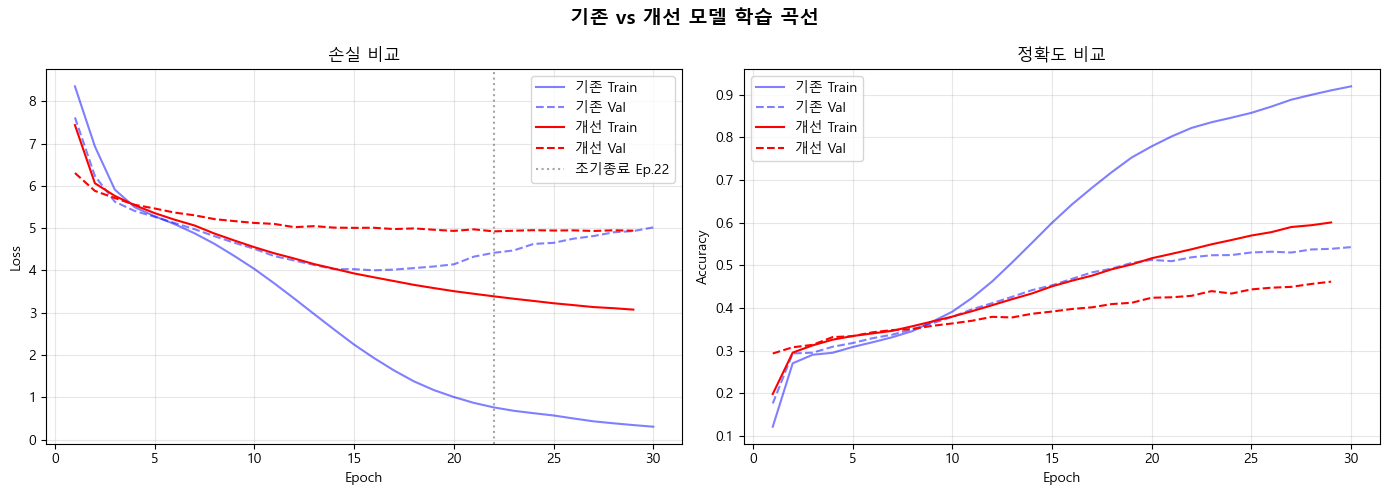

In [33]:
# ── 학습 곡선 비교 (기존 vs 개선) ─────────────────────────────────────
e1 = range(1, len(history['loss']) + 1)
e2 = range(1, len(history_v2['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(e1, history['loss'],        'b-',  alpha=0.5, label='기존 Train')
axes[0].plot(e1, history['val_loss'],    'b--', alpha=0.5, label='기존 Val')
axes[0].plot(e2, history_v2['loss'],     'r-',            label='개선 Train')
axes[0].plot(e2, history_v2['val_loss'], 'r--',           label='개선 Val')
axes[0].axvline(best_epoch, color='gray', linestyle=':', alpha=0.7, label=f'조기종료 Ep.{best_epoch}')
axes[0].set_title('손실 비교'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(e1, history['accuracy'],        'b-',  alpha=0.5, label='기존 Train')
axes[1].plot(e1, history['val_accuracy'],    'b--', alpha=0.5, label='기존 Val')
axes[1].plot(e2, history_v2['accuracy'],     'r-',            label='개선 Train')
axes[1].plot(e2, history_v2['val_accuracy'], 'r--',           label='개선 Val')
axes[1].set_title('정확도 비교'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('기존 vs 개선 모델 학습 곡선', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
def beam_search(sentence, beam_size=4, max_len=MAX_LEN):
    """Beam Search 기반 응답 생성 (model_v2 사용)"""
    sentence  = re.sub(r'[^가-힣a-zA-Z0-9\s!?.,~]', '', sentence.strip())
    enc_ids   = sp.encode_as_ids(sentence)[:max_len]
    enc_input = np.array([enc_ids + [PAD_ID] * (max_len - len(enc_ids))], dtype=np.int32)

    beams = [(0.0, [START_ID])]   # (누적 log-prob, 토큰 리스트)
    for _ in range(max_len):
        new_beams = []
        all_done  = True
        for score, tokens in beams:
            if tokens[-1] == END_ID:
                new_beams.append((score, tokens))
                continue
            all_done = False
            dec_arr  = np.array(
                [tokens + [PAD_ID] * (max_len - len(tokens))], dtype=np.int32
            )
            logits    = model_v2([enc_input, dec_arr], training=False)
            log_probs = tf.nn.log_softmax(logits[0, len(tokens) - 1], axis=-1).numpy()
            for tid in np.argsort(log_probs)[-beam_size:]:
                new_beams.append((score + log_probs[tid], tokens + [int(tid)]))

        # 길이 정규화 후 상위 beam_size 유지
        beams = sorted(new_beams, key=lambda x: x[0] / len(x[1]), reverse=True)[:beam_size]
        if all_done:
            break

    best_tokens = beams[0][1]
    return sp.decode_ids([t for t in best_tokens[1:] if t not in [END_ID, PAD_ID]])


# ── 기존(Greedy) vs 개선(Beam Search) 응답 비교 ───────────────────────
test_qs = ['안녕하세요', '오늘 기분이 어때요?', '심심한데 뭐 할까요?',
           '고마워요', '사랑해', '배고파', '힘들어요', '잘 자']

print(f'{"질문":<18} {"기존 Greedy":<24} {"개선 Beam Search"}')
print('─' * 72)
for q in test_qs:
    old = predict(q)        # 기존 model + greedy
    new = beam_search(q)    # model_v2  + beam search
    print(f'{q:<18} {old:<24} {new}')

# ── BLEU 비교 ─────────────────────────────────────────────────────────
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoother = SmoothingFunction().method1

def bleu_score(enc_inputs, dec_targets, predict_fn, n=100):
    scores, idxs = [], np.random.choice(len(enc_inputs), min(n, len(enc_inputs)), replace=False)
    for idx in idxs:
        q = sp.decode_ids([int(x) for x in enc_inputs[idx] if x != PAD_ID])
        if not q.strip():
            continue
        resp = predict_fn(q)
        ref  = sp.decode_ids([int(x) for x in dec_targets[idx]
                               if x not in [PAD_ID, START_ID, END_ID]])
        if resp and ref:
            scores.append(sentence_bleu([list(ref)], list(resp), smoothing_function=smoother))
    return np.mean(scores) if scores else 0.0

print('\nBLEU-1 계산 중...')
np.random.seed(42)
b1 = bleu_score(enc_test, dec_tgt_test, predict)
np.random.seed(42)
b2 = bleu_score(enc_test, dec_tgt_test, beam_search)
print(f'기존 모델 (Greedy):       BLEU-1 = {b1:.4f}')
print(f'개선 모델 (Beam Search):  BLEU-1 = {b2:.4f}')

질문                 기존 Greedy                개선 Beam Search
────────────────────────────────────────────────────────────────────────
안녕하세요              안녕하세요.                   맛있는 거 드세요.
오늘 기분이 어때요?        자신에게 더 여유롭게 대해보세요.       좋은 곳으로 데려다 줄 거예요.
심심한데 뭐 할까요?        저랑 이야기해요.                마음이 허전한가봐요.
고마워요               기억에서 지울 순 없지만 최대한 생각 말아보셔요. 많이 힘들지 않았으면 좋겠어요.
사랑해                상대방에게 전해보세요.             마음이 헛헛한가봐요.
배고파                얼른 맛난 음식 드세요.            맛있게 드세요.
힘들어요               정정기간을 노려 보세요.            많이 힘들지 않았으면 좋겠어요.
잘 자                잘자요,                     많이 힘들지 않았으면 좋겠어요.

BLEU-1 계산 중...
기존 모델 (Greedy):       BLEU-1 = 0.1092
개선 모델 (Beam Search):  BLEU-1 = 0.0514


BLEU 점수가 더 낮아졌다...